# Funzioni per generare i grafi

In [ ]:














! pip install leidenalg -q #libreria che implementa l'algoritmo di Leiden

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 91.8 MB/s eta 0:00:00


In [ ]:
! pip install cdlib -q #community detection library, la uso per la NMI

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.3/314.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 21.3 MB/s eta 0:00:00


In [ ]:
! pip install pyvis -q #libreria per la visualizzazione dei grafi

In [ ]:
from pyvis.network import Network

In [ ]:
import math
import random
import numpy as np
import copy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.ticker import LinearLocator

import networkx as nx
import igraph as ig
import leidenalg

from cdlib import evaluation

In [ ]:
def genera_dimensioni (n, fun, min_communitysize, max_communitysize, argomenti):

        seq = []
        while not sum(seq) >= n:

            nodi_c = fun(*argomenti, min_communitysize-1)

            if min_communitysize <= nodi_c <= max_communitysize:
                seq.append(nodi_c)

        eccesso = sum(seq) - n

        if eccesso > 0 and eccesso > sum(seq) - (min_communitysize*len(seq)):
          return genera_dimensioni(n, fun, min_communitysize, max_communitysize, argomenti)

        if eccesso > 0:
          seq = sorted(seq, reverse=True)
          i=0
          bigger_communities = []
          while i<len(seq) and seq[i] > min_communitysize:
            bigger_communities.append(i)
            i+=1

        while eccesso > 0:
              c_idx = random.choice(bigger_communities)
              c_dim = seq[c_idx]
              seq[c_idx] -= 1
              eccesso -= 1
              if c_dim-1 == min_communitysize:
                  bigger_communities.pop(bigger_communities.index(c_idx))

        return sorted(seq, reverse=True)

In [ ]:
def genera_grado (n, fun, min_grado, max_grado, argomenti):

        seq = []
        while len(seq) < n:
            grado = fun(*argomenti, min_grado-1)

            if min_grado <= grado <= max_grado:
                seq.append(grado)

        if sum(seq) % 2 == 1:
            seq[0] = seq[0] + 1
        return sorted(seq, reverse=True)

In [ ]:
def genera_comunità (gradi, dimensioni, mu, max_iters):
  n = len(gradi)
  result = [set() for _ in dimensioni]
  free = list(range(n))
  n_comunità = len(dimensioni)
  notfull = list(range(n_comunità))
  i=0
  dim_possibili = []
  for j in range(n):
        v = free.pop(0)

        s = round(gradi[v] * (1 - mu))
        while i < n_comunità and s <= dimensioni[i]:
          if i in notfull:
            dim_possibili.append(i)
            i+=1

        c = random.choice(dim_possibili)
        result[c].add(v)

        if len(result[c]) == dimensioni[c]:
          notfull.pop(notfull.index(c))
          dim_possibili.pop(dim_possibili.index(c))
  return result


In [ ]:
def genera_grafo (n, mu, gradi, comunità):

    G = nx.Graph()
    G.add_nodes_from(range(n), label=[str(i) for i in range(n)])
    for c in comunità:
            for u in c:
                nodi_disp_c = list(c)

                while G.degree(u) < round(gradi[u] * (1 - mu)):
                    v = random.choice(nodi_disp_c)
                    nodi_disp_c.pop(nodi_disp_c.index(v))
                    G.add_edge(u, v)

                while G.degree(u) < gradi[u]:
                    v = random.choice(range(n))
                    if v not in c:
                        G.add_edge(u, v)

                G.nodes[u]["group"] = comunità.index(c)
                G.nodes[u]["title"] = f'comunità {comunità.index(c)}'
                G.nodes[u]["label"] = str(u)
    return G

In [ ]:
def genera_html (G, partizione, titolo, fixed=False):
  for comunità in partizione:
    for v in comunità:
      indice_comunità = partizione.index(comunità)
      G.nodes[v]["group"] = str(indice_comunità)
      G.nodes[v]["title"] = f'comunità {indice_comunità}'
      G.nodes[v]["fixed"] = fixed

  net = Network(height="750px", width="100%", bgcolor="#FFFFFF", font_color="black")
  net.from_nx(G)
  net.show_buttons(filter_=['physics'])
  net.show(f'{titolo}.html', notebook=False)

In [ ]:
def istogrammi_gradi_dimensioni (gradi, dimensioni):
    fig, axs = matplotlib.pyplot.subplots(2)
    fig.suptitle('Distribuzioni dei gradi dei nodi e delle dimensioni delle comunità')
    fig.subplots_adjust(hspace=0.3)
    axs[0].hist(gradi, bins=50, log=False)
    axs[0].set(xlabel='gradi dei nodi', ylabel='numero di nodi')
    axs[0].plot()
    axs[1].hist(dimensioni, bins=50, log=False)
    axs[1].set(xlabel='dimensioni delle comunità',ylabel='numero di comunità')
    axs[1].plot()

In [ ]:
def ellisse (n, r, centro=(0, 0)):
    cx, cy = centro
    punti = []

    for i in range(n):
        theta = 2 * math.pi * i / n
        x = cx + (1.5)*r * math.cos(theta)
        y = cy + r * math.sin(theta)
        punti.append((x, y))

    return punti

In [ ]:
def disponi_comunità (G, comunità):
    punti = ellisse(len(comunità), 4000)
    pos = {}
    offsets = punti
    for i in range(len(comunità)):
        nodes = list(comunità[i])
        subgraph = G.subgraph(nodes)
        sub_pos = nx.spring_layout(
                                    subgraph,
                                    scale=500,
                                    k=0.7,          #distanza tra i nodi
                                    iterations=50,
                                    seed=42
                                )
        ox, oy = offsets[i]
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + ox, y + oy)

    attributi = {}
    for u in G.nodes:
       attributi[u] = {'group':G.nodes[u]["group"],'title':G.nodes[u]["title"],'label':str(u),'x':pos[u][0],'y':pos[u][1], 'fixed':True}
    nx.set_node_attributes(G, attributi)
    return G

# Funzioni per l'analisi sui grafi

In [ ]:
def import_nx_network(net):
    graph = ig.Graph(n=net.number_of_nodes(), directed=False)
    graph.add_edges(net.edges())

    return graph

In [ ]:
def tridimensional_plot(X, Y, Z, cmap, titolo, ylabel=None):
    X, Y = np.meshgrid(X, Y)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    #ax.view_init(elev=30, azim=45, roll=15)
    surf = ax.plot_surface(X, Y, Z, cmap=cmap,
                       linewidth=0, antialiased=False)
    ax.set(xlabel='mu', ylabel=ylabel)
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax.set_title(titolo)
    plt.show()

In [ ]:
def confronto_louvain_leiden(G_nx, nome, print_partizioni=False, comunità_planted=None):

  # Si fanno eseguire sul grafo in input gli algoritmi di Louvain e Leiden delle librerie networkx e igraph:

  G_ig = import_nx_network(G_nx)
  comunità_louvain = nx.community.louvain_communities(G_nx, weight='weight', resolution=0.7, threshold=1e-07, max_level=None, seed=None)
  comunità_leiden = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
  comunità_leiden_cpm = leidenalg.find_partition(G_ig, leidenalg.CPMVertexPartition, resolution_parameter = 0.07)
  '''
  partition = leidenalg.CPMVertexPartition(G_ig,)
  optimiser = leidenalg.Optimiser()
  diff = optimiser.optimise_partition(partition)
  '''
  # La modularità è calcolata da una funzione della libreria networkx
  louvain_modularità = nx.community.modularity(G_nx, comunità_louvain, weight='weight', resolution=1)
  leiden_modularità = nx.community.modularity(G_nx, comunità_leiden, weight='weight', resolution=1)
  leiden_cpm_modularità = nx.community.modularity(G_nx, comunità_leiden_cpm, weight='weight', resolution=1)

  if comunità_planted!=None:
      planted_modularità = nx.community.modularity(G_nx, comunità_planted, weight='weight', resolution=1)
      comunità_planted = lista_di_liste (comunità_planted, 'comunità planted del grafo:', Print=print_partizioni)

  comunità_louvain = lista_di_liste (comunità_louvain, 'comunità trovate con Louvain:', Print=print_partizioni)
  comunità_leiden = lista_di_liste (comunità_leiden, 'comunità trovate con Leiden (modularità):', Print=print_partizioni)
  comunità_leiden_cpm = lista_di_liste (comunità_leiden_cpm, 'comunità trovate con Leiden (cpm):', Print=print_partizioni)


  if comunità_planted!=None:
      print(f'Numero delle comunità planted: {len(comunità_planted)}, la partizione ha modularità {planted_modularità},')
  print(f'Numero delle comunità trovate da louvain: {len(comunità_louvain)}, la partizione ha modularità {louvain_modularità},\nNumero delle comunità trovate da leiden (modularità): {len(comunità_leiden)}, la partizione ha modularità {leiden_modularità},\n Numero delle comunità trovate da leiden (cpm): {len(comunità_leiden_cpm)}, la partizione ha modularità {leiden_cpm_modularità}\n')
  # Visualizzazione del grafo con i nodi colorati a seconda della partizione con la libreria pyvis
  print('Generazione degli html con la visualizzazione delle partizioni del grafo:')
  genera_html (G_nx, comunità_louvain, f'Louvain_{nome}')
  genera_html (G_nx, comunità_louvain, f'Louvain_ellisse_{nome}', fixed=True)
  genera_html (G_nx, comunità_leiden, f'Leiden_mod_{nome}')
  genera_html (G_nx, comunità_leiden, f'Leiden_mod_ellisse_{nome}', fixed=True)
  genera_html (G_nx, comunità_leiden_cpm, f'Leiden_cpm_{nome}')
  genera_html (G_nx, comunità_leiden_cpm, f'Leiden_cpm_ellisse{nome}', fixed=True)


  print('\n')
  # Informazione mutua normalizzata tra le partizioni trovate (misura di quanto sono simili)

  comunità_louvain = Partition(comunità_louvain)
  comunità_leiden = Partition(comunità_leiden)
  comunità_leiden_cpm = Partition(comunità_leiden_cpm)

  print(f'coefficiente di clustering del grafo: {nx.average_clustering(G_nx)}')

  if comunità_planted!=None:
    comunità_planted = Partition(comunità_planted)
    print(f'NMI tra la partizione originale del grafo e quella trovata da Louvain: {float(evaluation.normalized_mutual_information(comunità_planted, comunità_louvain)[0])}')
    print(f'NMI tra la partizione originale del grafo e quella trovata da Leiden (modularità): {float(evaluation.normalized_mutual_information(comunità_planted, comunità_leiden)[0])}')
    print(f'NMI tra la partizione originale del grafo e quella trovata da Leiden (cpm): {float(evaluation.normalized_mutual_information(comunità_planted, comunità_leiden_cpm)[0])}')

  print(f'NMI tra le partizioni trovate da Louvain e Leiden (mod): {float(evaluation.normalized_mutual_information(comunità_louvain, comunità_leiden)[0])}')
  print(f'NMI tra le partizioni trovate da Leiden (mod) e Leiden (cpm): {float(evaluation.normalized_mutual_information(comunità_leiden, comunità_leiden_cpm)[0])}')


In [ ]:
def matrice_partizioni_res (grafi_partizioni, int_res):
  lista_esterna = []
  for i in range (len(grafi_partizioni)):
        lista_interna = []
        p_res = partizioni_resolution_parameter(grafi_partizioni[i][0], int_res)
        for j in range (len(p_res)):
            lista_interna.append(float(evaluation.normalized_mutual_information(Partition(grafi_partizioni[i][1]), Partition(p_res[j]))[0]))
        lista_esterna.append(lista_interna)
        print(i)

  return np.array(lista_esterna).transpose()

In [ ]:
def partizioni_resolution_parameter (grafo, intervalli):
    G_ig = import_nx_network(grafo)
    partizioni = []
    gamma = 0
    while gamma <= 1:
        partizioni.append(leidenalg.find_partition(G_ig, leidenalg.CPMVertexPartition, resolution_parameter = gamma))
        gamma += 1/intervalli
    return partizioni

In [ ]:
def visualizza_NMI_leiden_cpm (grafo, partizione_planted, partizioni_res):
  intervalli = len(partizioni_res)
  valori = []
  for p_res in partizioni_res:
    valori.append(float(evaluation.normalized_mutual_information(Partition(partizione_planted), Partition(p_res))[0]))

  print(f'massimo della NMI: {max(valori)}, per gamma: {valori.index(max(valori))*(1/intervalli)}')

  fig, ax = matplotlib.pyplot.subplots(1,1)
  ax.plot(np.linspace(0, 1, num=intervalli), valori)
  ax.set_title('NMI delle partizioni trovate da Leiden (cpm)')
  ax.set(xlabel='gamma', ylabel='NMI')

### Coefficiente di clustering

In [ ]:
def coefficiente_clustering_grafico (grafi_partizioni):
  intervalli = len(grafi_partizioni)
  coefficienti = []
  for g,p in grafi_partizioni:
    coefficienti.append(nx.average_clustering(g))

  fig, ax = matplotlib.pyplot.subplots(1,1)
  ax.plot(np.linspace(0, 1, num=intervalli), coefficienti)
  ax.set_title('coefficiente di clustering dei grafi in funzione di mu')
  ax.set(xlabel='mu', ylabel='coefficiente di clustering')

In [ ]:
def matrice_coefficiente_clustering (grafi_partizioni, it_interne, it_esterne):
    lista_esterna = []
    for i in range (it_esterne):
        lista_interna = []
        for j in range (it_interne):
            lista_interna.append(nx.average_clustering(grafi_partizioni[(i*it_interne) + j][0]))
        lista_esterna.append(lista_interna)
        print(i)

    matrice = np.array(lista_esterna)
    return matrice

### Modularità

In [ ]:
def matrice_modularità (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm, it_interne, it_esterne):

    lista_esterna_planted = []
    lista_esterna_louvain = []
    lista_esterna_leiden = []
    lista_esterna_leiden_cpm = []
    for i in range (it_esterne):
        lista_interna_planted = []
        lista_interna_louvain = []
        lista_interna_leiden = []
        lista_interna_leiden_cpm = []
        for j in range (it_interne):
            lista_interna_planted.append(nx.community.modularity(grafi_partizioni[(i*it_interne) + j][0], grafi_partizioni[(i*it_interne) + j][1], resolution=1))
            lista_interna_louvain.append(nx.community.modularity(grafi_partizioni[(i*it_interne) + j][0], lista_louvain[(i*it_interne) + j], resolution=1))
            lista_interna_leiden.append(nx.community.modularity(grafi_partizioni[(i*it_interne) + j][0], lista_leiden[(i*it_interne) + j], resolution=1))
            lista_interna_leiden_cpm.append(nx.community.modularity(grafi_partizioni[(i*it_interne) + j][0], lista_leiden_cpm[(i*it_interne) + j], resolution=1))
        lista_esterna_planted.append(lista_interna_planted)
        lista_esterna_louvain.append(lista_interna_louvain)
        lista_esterna_leiden.append(lista_interna_leiden)
        lista_esterna_leiden_cpm.append(lista_interna_leiden_cpm)
        print(i)

    matrice_planted = np.array(lista_esterna_planted)
    matrice_louvain = np.array(lista_esterna_louvain)
    matrice_leiden = np.array(lista_esterna_leiden)
    matrice_leiden_cpm = np.array(lista_esterna_leiden_cpm)
    return matrice_planted, matrice_louvain, matrice_leiden, matrice_leiden_cpm

In [ ]:
def liste_louvain_leiden (grafi_partizioni, lista_gamma):
    lista_louvain = []
    lista_leiden = []
    lista_leiden_cpm = []
    for i in range (len(grafi_partizioni)):
            G_nx = grafi_partizioni[i][0]
            lista_louvain.append(nx.community.louvain_communities(G_nx))
            G_ig = import_nx_network(G_nx)
            lista_leiden.append(leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition))
            lista_leiden_cpm.append(leidenalg.find_partition(G_ig, leidenalg.CPMVertexPartition, resolution_parameter = lista_gamma[i]))
            if i%100 == 0:
              print(i/100)

    return lista_louvain, lista_leiden, lista_leiden_cpm

In [ ]:
def modularità_grafico (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm):
  lista_modularità_planted = []
  lista_modularità_louvain = []
  lista_modularità_leiden = []
  lista_modularità_leiden_cpm = []

  for i in range(len(grafi_partizioni)):
        grafo = grafi_partizioni[i][0]
        partizione = grafi_partizioni[i][1]
        lista_modularità_planted.append(nx.community.modularity(grafo, partizione, resolution=1))
        lista_modularità_louvain.append(nx.community.modularity(grafo, lista_louvain[i], resolution=1))
        lista_modularità_leiden.append(nx.community.modularity(grafo, lista_leiden[i], resolution=1))
        lista_modularità_leiden_cpm.append(nx.community.modularity(grafo, lista_leiden_cpm[i], resolution=1))

  intervalli = len(lista_modularità_louvain)
  fig, axs = matplotlib.pyplot.subplots(3,2, figsize=(6, 8))
  fig.subplots_adjust(hspace=0.5, wspace=0.5)
  fig.suptitle('Modularità in funzione di mu')
  axs[0,0].plot(np.linspace(0, 1, num=intervalli), lista_modularità_planted, 'tab:cyan')
  axs[0,0].set_title('partizione planted')
  axs[0,1].plot(np.linspace(0, 1, num=intervalli), lista_modularità_louvain, 'tab:pink')
  axs[0,1].set_title('partizione di Louvain')
  axs[1,0].plot(np.linspace(0, 1, num=intervalli), lista_modularità_leiden, 'tab:purple')
  axs[1,0].set_title('partizione di Leiden (mod)')
  axs[1,1].plot(np.linspace(0, 1, num=intervalli), lista_modularità_leiden_cpm, 'tab:red')
  axs[1,1].set_title('partizione di Leiden (cpm)')
  axs[2,0].plot(np.linspace(0, 1, num=intervalli), lista_modularità_planted, 'tab:cyan')
  axs[2,0].plot(np.linspace(0, 1, num=intervalli), lista_modularità_louvain, 'tab:pink')
  axs[2,0].plot(np.linspace(0, 1, num=intervalli), lista_modularità_leiden, 'tab:purple')
  axs[2,0].plot(np.linspace(0, 1, num=intervalli), lista_modularità_leiden_cpm, 'tab:red')
  axs[2,0].set_title('sovrapposizione dei grafici')

  for ax in axs.flat:
      ax.set(xlabel='mu', ylabel='Modularità')
  '''
  for ax in axs.flat:
      ax.label_outer()
  '''

### Normalized Mutual Information

In [ ]:
# cdlib ha bisogno di un oggetto con questi attributi per fare il calcolo della NMI
class Partition:
  def __init__(self, communities):
    self.communities = sorted(list(communities))
    self.overlap = False

In [ ]:
# Trasformo le partizioni trovate in liste di liste,
# mi serve per la visualizzazione e per la NMI
def lista_di_liste (partizione, titolo, Print=False):
  if Print == True:
        print (titolo)
  lista_partizione = []
  for c in partizione:
      lista_comunità = sorted(list(c))
      lista_partizione.append(lista_comunità)
      if Print == True:
        print (lista_comunità, f'Numero di elementi nella comunità: {len(lista_comunità)}')
  if Print == True:
        print ('\n')
  return lista_partizione

In [ ]:
def liste_NMI (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm):
    lista_NMI_louvain = []
    lista_NMI_leiden = []
    lista_NMI_leiden_cpm = []
    lista_NMI_loulei = []

    for i in range(len(grafi_partizioni)):

        partizione = grafi_partizioni[i][1]
        louvain = lista_louvain[i]
        leiden = lista_leiden[i]
        leiden_cpm = lista_leiden_cpm[i]

        NMI_louvain = float(evaluation.normalized_mutual_information(Partition(partizione), Partition(louvain))[0])
        NMI_leiden = float(evaluation.normalized_mutual_information(Partition(partizione), Partition(leiden))[0])
        NMI_leiden_cpm = float(evaluation.normalized_mutual_information(Partition(partizione), Partition(leiden_cpm))[0])
        NMI_loulei = float(evaluation.normalized_mutual_information(Partition(louvain), Partition(leiden))[0])
        lista_NMI_louvain.append(NMI_louvain)
        lista_NMI_leiden.append(NMI_leiden)
        lista_NMI_leiden_cpm.append(NMI_leiden_cpm)
        lista_NMI_loulei.append(NMI_loulei)
        #print(i)
        i+=1

    return lista_NMI_louvain, lista_NMI_leiden, lista_NMI_leiden_cpm, lista_NMI_loulei

In [ ]:
def matrice_NMI (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm, it_interne, it_esterne):
  matrice_NMI_louvain = []
  matrice_NMI_leiden = []
  matrice_NMI_leiden_cpm = []
  matrice_NMI_loulei = []

  for i in range (it_esterne):

    lista1 = grafi_partizioni[it_interne*i:it_interne*(i+1)]
    lista2 = lista_louvain[it_interne*i:it_interne*(i+1)]
    lista3 = lista_leiden[it_interne*i:it_interne*(i+1)]
    lista4 = lista_leiden_cpm[it_interne*i:it_interne*(i+1)]

    lista_NMI_louvain, lista_NMI_leiden, lista_NMI_leiden_cpm, lista_NMI_loulei = liste_NMI (lista1, lista2, lista3, lista4)
    matrice_NMI_louvain.append(lista_NMI_louvain)
    matrice_NMI_leiden.append(lista_NMI_leiden)
    matrice_NMI_leiden_cpm.append(lista_NMI_leiden_cpm)
    matrice_NMI_loulei.append(lista_NMI_loulei)
    print(i)

  return np.array(matrice_NMI_louvain), np.array(matrice_NMI_leiden), np.array(matrice_NMI_leiden_cpm), np.array(matrice_NMI_loulei)

In [ ]:
def NMI_grafico (lista_NMI_louvain, lista_NMI_leiden, lista_NMI_leiden_cpm, lista_NMI_loulei):

  intervalli = len(lista_NMI_louvain)
  fig, axs = matplotlib.pyplot.subplots(3,2, figsize=(6, 8))
  fig.subplots_adjust(hspace=0.5, wspace=0.5)
  fig.suptitle('Informazione mutua normalizzata in funzione di mu')
  axs[0,0].plot(np.linspace(0, 1, num=intervalli), lista_NMI_louvain)
  axs[0,0].set_title('louvain-planted')
  axs[0,1].plot(np.linspace(0, 1, num=intervalli), lista_NMI_leiden, 'tab:orange')
  axs[0,1].set_title('leiden(mod)-planted')
  axs[1,0].plot(np.linspace(0, 1, num=intervalli), lista_NMI_leiden_cpm, 'tab:grey')
  axs[1,0].set_title('leiden(cpm)-planted')
  axs[2,0].plot(np.linspace(0, 1, num=intervalli), lista_NMI_loulei, 'tab:green')
  axs[2,0].set_title('louvain-leiden(mod)')
  axs[1,1].plot(np.linspace(0, 1, num=intervalli), lista_NMI_louvain)
  axs[1,1].plot(np.linspace(0, 1, num=intervalli), lista_NMI_leiden, 'tab:orange')
  axs[1,1].plot(np.linspace(0, 1, num=intervalli), lista_NMI_leiden_cpm, 'tab:grey')
  #axs[2,0].plot(np.linspace(0, 1, num=intervalli), lista_NMI_loulei, 'tab:green')
  axs[1,1].set_title('sovrapposizione dei grafici')

  for ax in axs.flat:
      ax.set(xlabel='mu', ylabel='NMI')
  '''
  for ax in axs.flat:
      ax.label_outer()
  '''

# Analisi su un singolo grafo

In [ ]:
def mia_benchmark (n, fun1, fun2, min_grado, min_communitysize, max_communitysize, mu, argomenti1, argomenti2):

    dimensioni = genera_dimensioni (n, fun2, min_communitysize, max_communitysize, argomenti2)
    gradi = genera_grado (n, fun1, min_grado, max(dimensioni), argomenti1)
    print(f'numero atteso del grado {sum(gradi)/len(gradi)}')

    istogrammi_gradi_dimensioni (gradi, dimensioni)
    comunità = genera_comunità (gradi, dimensioni, mu, 10000)

    G = genera_grafo (n, mu, gradi, comunità)
    print(f'numero di archi nella rete: {len(G.edges())}')
    html1 = genera_html (G, comunità, 'grafo')

    G = disponi_comunità (G, comunità)
    html2 = genera_html (G, comunità, 'grafo_ellisse', fixed=True)

    return G, comunità

In [ ]:
from scipy.stats import randint, poisson, geom

In [ ]:
# GEOMETRICA
'''
n = 500
min_communitysize = 30
max_communitysize = 200
min_grado = 3
mu = 0.3

fun1 = geom.rvs
fun2 = geom.rvs
fun1_nome = 'geom'
fun2_nome = 'geom'

p1 = 0.5 #geom gradi
p2 = 0.5 #geom dimensioni comunità

arg1 = (p1,)
arg2 = (p2,)

arr_min_grado = np.array(list(range(1,21)))
'''

"\nn = 500\nmin_communitysize = 30\nmax_communitysize = 200\nmin_grado = 3\nmu = 0.3\n\nfun1 = geom.rvs\nfun2 = geom.rvs\nfun1_nome = 'geom'\nfun2_nome = 'geom'\n\np1 = 0.5 #geom gradi\np2 = 0.5 #geom dimensioni comunità\n\narg1 = (p1,)\narg2 = (p2,)\n\narr_min_grado = np.array(list(range(1,21)))\n"

In [ ]:
'''
# POISSON

n = 100
min_communitysize = 50
max_communitysize = 50
min_grado = 1
mu = 1

fun1 = poisson.rvs
fun2 = poisson.rvs
fun1_nome = 'poisson'
fun2_nome = 'poisson'

l1 = 2 #media distribuzione di poisson dei gradi (prima dello shift dato da min_grado)
l2 = 4 #media distribuzione di poisson delle dimensioni delle comunità (prima dello shift dato da min_communitysize)

arg1 = (l1,)
arg2 = (l2,)

arr_min_grado = np.array(list(range(1,51)))
'''

"\n# POISSON\n\nn = 100\nmin_communitysize = 50\nmax_communitysize = 50\nmin_grado = 1\nmu = 1\n\nfun1 = poisson.rvs\nfun2 = poisson.rvs\nfun1_nome = 'poisson'\nfun2_nome = 'poisson'\n\nl1 = 2 #media distribuzione di poisson dei gradi (prima dello shift dato da min_grado)\nl2 = 4 #media distribuzione di poisson delle dimensioni delle comunità (prima dello shift dato da min_communitysize)\n\narg1 = (l1,)\narg2 = (l2,)\n\narr_min_grado = np.array(list(range(1,51)))\n"

In [ ]:
#ZIPF

n = 1000
min_communitysize = 30
max_communitysize = 200
min_grado = 6
mu = 0.1

# distribuzioni discrete: nx.utils.zipf_rv, randint.rvs, poisson.rvs, geom.rvs
fun1 = nx.utils.zipf_rv
fun2 = nx.utils.zipf_rv
fun1_nome = 'zipf'
fun2_nome = 'zipf'

tau1 = 2 #esponente plaw gradi
tau2 = 1.1 #esponente plaw dimensioni comunità

arg1 = (tau1,) # poisson:(l1,), geom:(p1,) zipf:(tau1, min_grado) randint:(min_grado, max(dimensioni))
arg2 = (tau2,) # poisson:(l2,), geom:p2,) zipf:(tau2, min_communitysize) randint:(min_communitysize, max_communitysize)

arr_min_grado = np.array(list(range(2,22)))


numero atteso del grado 18.438
numero di archi nella rete: 11318
grafo.html
grafo_ellisse.html


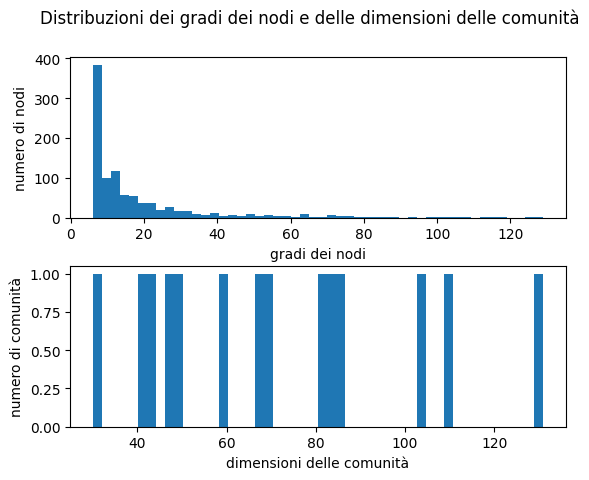

In [ ]:
grafo, partizione = mia_benchmark (n, fun1, fun2, min_grado, min_communitysize, max_communitysize, mu, arg1, arg2)

In [ ]:
confronto_louvain_leiden (grafo, f'{fun1_nome}_{fun2_nome}', print_partizioni=True, comunità_planted=partizione)

comunità planted del grafo:
[0, 1, 2, 3, 4, 10, 11, 12, 13, 14, 21, 27, 29, 33, 44, 52, 53, 56, 61, 62, 72, 124, 135, 138, 142, 157, 173, 174, 178, 187, 191, 207, 274, 283, 284, 285, 291, 304, 305, 339, 348, 350, 364, 397, 409, 418, 426, 427, 451, 465, 493, 508, 522, 523, 540, 573, 582, 592, 593, 600, 614, 635, 657, 677, 684, 689, 696, 719, 722, 724, 728, 748, 750, 758, 762, 785, 788, 799, 800, 804, 813, 832, 838, 846, 869, 887, 892, 895, 896, 907, 908, 918, 925, 929, 930, 936, 937, 939, 940, 942, 946, 947, 948, 953, 955, 956, 957, 959, 962, 973, 974, 976, 979, 980, 981, 983, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 999] Numero di elementi nella comunità: 131
[5, 8, 9, 24, 28, 30, 35, 51, 77, 94, 156, 162, 190, 200, 215, 218, 223, 240, 245, 248, 256, 265, 275, 276, 281, 297, 308, 310, 318, 334, 336, 375, 377, 378, 394, 401, 403, 411, 423, 441, 445, 461, 467, 470, 490, 496, 498, 504, 525, 536, 538, 545, 552, 556, 569, 572, 576, 587, 589, 594, 602, 617, 639, 

In [ ]:
partizioni_res = partizioni_resolution_parameter (grafo, 100)

massimo della NMI: 1.0, per gamma: 0.01


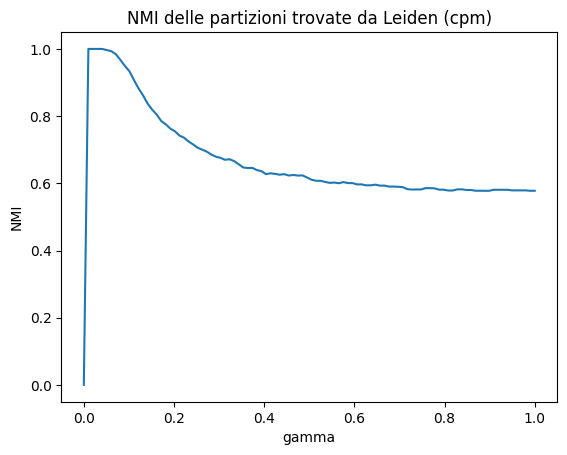

In [ ]:
visualizza_NMI_leiden_cpm (grafo, partizione, partizioni_res)

# Analisi su grafi generati al variare di mu

In [ ]:
def mia_benchmark_varia_mu (n, fun1, fun2, min_grado, min_communitysize, max_communitysize, argomenti1, argomenti2, intervalli_mu):

    dimensioni = genera_dimensioni (n, fun2, min_communitysize, max_communitysize, argomenti2)
    gradi = genera_grado (n, fun1, min_grado, max(dimensioni), argomenti1)

    istogrammi_gradi_dimensioni (gradi, dimensioni)
    res = []

    mu=0

    while mu <= 1:

        comunità = genera_comunità (gradi, dimensioni, mu, 10000)

        G = genera_grafo (n, mu, gradi, comunità)

        G = disponi_comunità (G, comunità)

        res.append((G, comunità))
        #print(mu)
        mu += 1/intervalli_mu

    return res

In [ ]:
intervalli_mu = 100

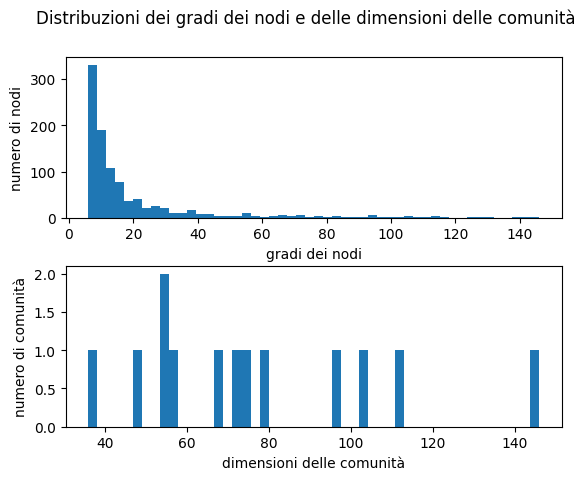

In [ ]:
grafi_partizioni = mia_benchmark_varia_mu (n, fun1, fun2, min_grado, min_communitysize, max_communitysize, arg1, arg2, intervalli_mu)

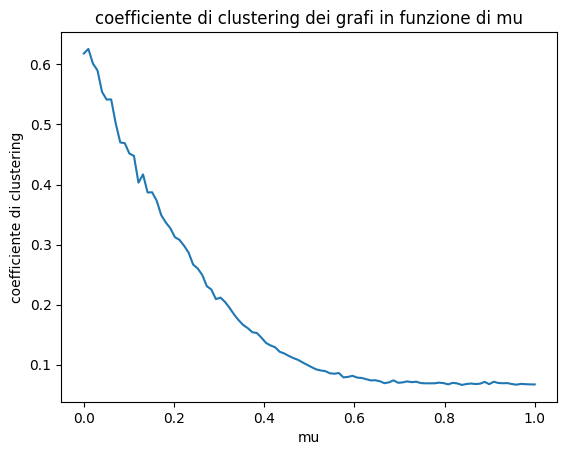

In [ ]:
coefficiente_clustering_grafico (grafi_partizioni)

In [44]:
intervalli_res = 100
mat_leiden_res = matrice_partizioni_res (grafi_partizioni, intervalli_res)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [45]:
X = np.linspace(0, 1, intervalli_mu)
Y = np.linspace(0, 1, intervalli_res)

In [46]:
np.max(mat_leiden_res)

np.float64(1.0000000000000002)

In [59]:
lista_gamma = []
lista_NMI = []
for l in list(mat_leiden_res.transpose()):
  lista_gamma.append((list(l).index(max(list(l)))/100))
  lista_NMI.append(max(list(l)))

In [48]:
'''
lista_gamma=[0.0,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.02,
  0.01,
  0.01,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.03,
  0.03,
  0.03,
  0.03,
  0.02,
  0.02,
  0.04,
  0.02,
  0.02,
  0.03,
  0.03,
  0.03,
  0.03,
  0.04,
  0.05,
  0.04,
  0.05,
  0.04,
  0.07,
  0.06,
  0.1,
  0.07,
  0.07,
  0.67,
  0.58,
  0.67,
  0.83,
  0.78,
  0.75,
  0.67,
  0.77,
  0.73,
  0.75,
  0.68,
  0.68,
  0.91,
  0.97,
  0.77,
  0.93,
  0.67,
  0.93,
  0.67,
  0.67,
  0.74,
  0.7,
  0.76,
  0.94,
  0.74,
  0.88,
  0.84,
  0.96,
  0.99,
  0.98,
  0.67,
  0.67,
  0.75,
  0.86,
  0.68,
  0.92,
  0.67,
  0.7,
  0.95,
  0.67,
  0.96,
  0.89,
  0.67,
  0.83]
'''

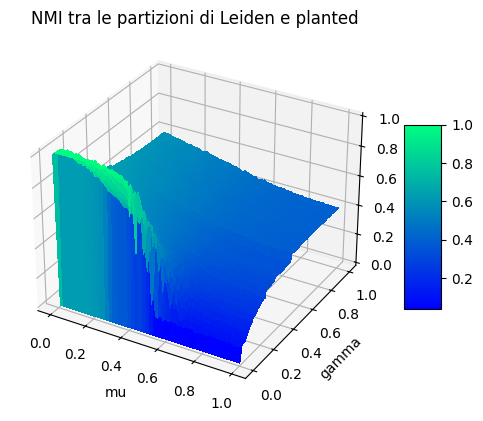

In [60]:
tridimensional_plot(X, Y, mat_leiden_res, cm.winter, 'NMI tra le partizioni di Leiden e planted', 'gamma' )

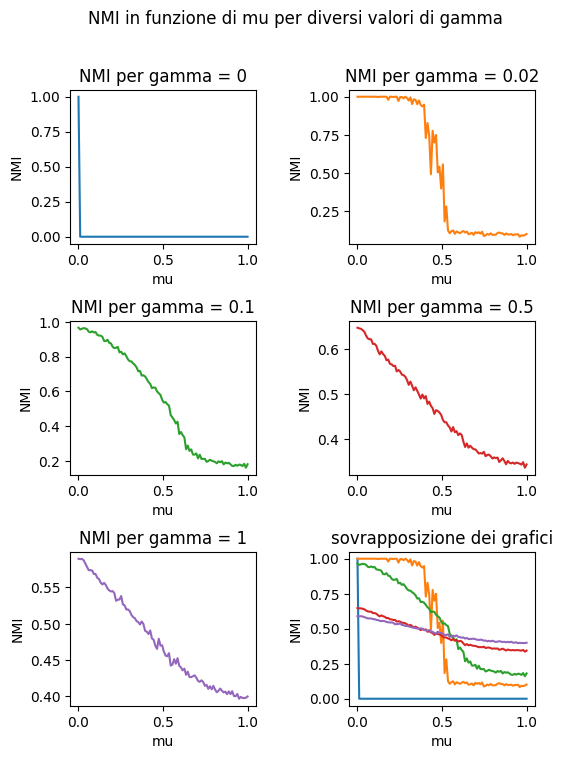

In [50]:
fig, axs = matplotlib.pyplot.subplots(3,2, figsize=(6, 8))
fig.subplots_adjust(hspace=0.5, wspace=0.5)
fig.suptitle('NMI in funzione di mu per diversi valori di gamma')
axs[0,0].plot(X, mat_leiden_res[0])
axs[0,0].set_title('NMI per gamma = 0')
axs[0,1].plot(X, mat_leiden_res[2], 'tab:orange')
axs[0,1].set_title('NMI per gamma = 0.02')
axs[1,0].plot(X, mat_leiden_res[10], 'tab:green')
axs[1,0].set_title('NMI per gamma = 0.1')
axs[1,1].plot(X, mat_leiden_res[49], 'tab:red')
axs[1,1].set_title('NMI per gamma = 0.5')
axs[2,0].plot(X, mat_leiden_res[99], 'tab:purple')
axs[2,0].set_title('NMI per gamma = 1')
axs[2,1].plot(X, mat_leiden_res[0])
axs[2,1].plot(X, mat_leiden_res[2])
axs[2,1].plot(X, mat_leiden_res[10])
axs[2,1].plot(X, mat_leiden_res[49])
axs[2,1].plot(X, mat_leiden_res[99])
axs[2,1].set_title('sovrapposizione dei grafici')

for ax in axs.flat:
      ax.set(xlabel='mu', ylabel='NMI')

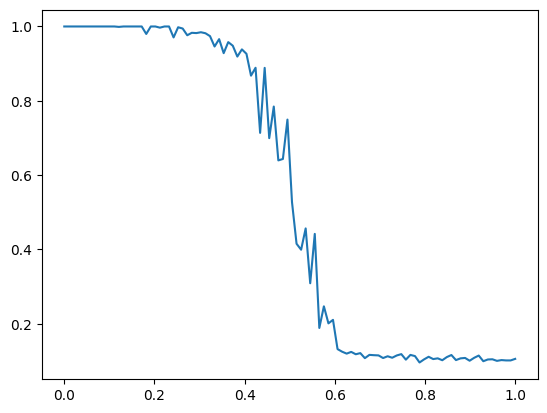

In [51]:
plt.plot(X, mat_leiden_res[3])

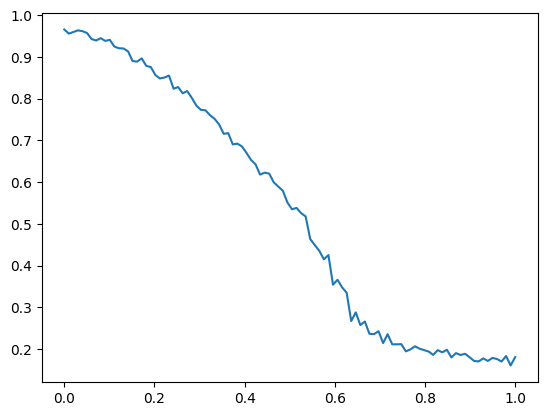

In [52]:
plt.plot(X, mat_leiden_res[10])

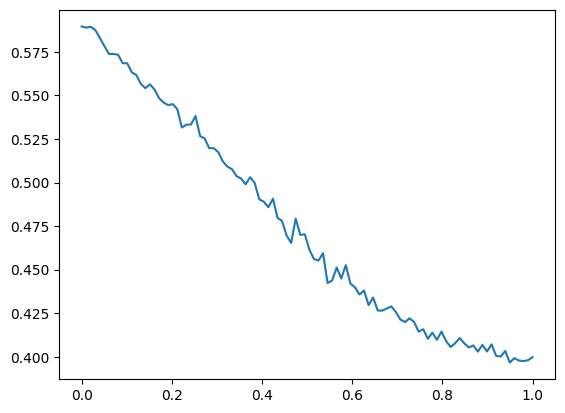

In [53]:
plt.plot(X, mat_leiden_res[99])

In [54]:
len(grafi_partizioni)

100

In [55]:
lista_louvain, lista_leiden, lista_leiden_cpm = liste_louvain_leiden (grafi_partizioni, lista_gamma)

0.0


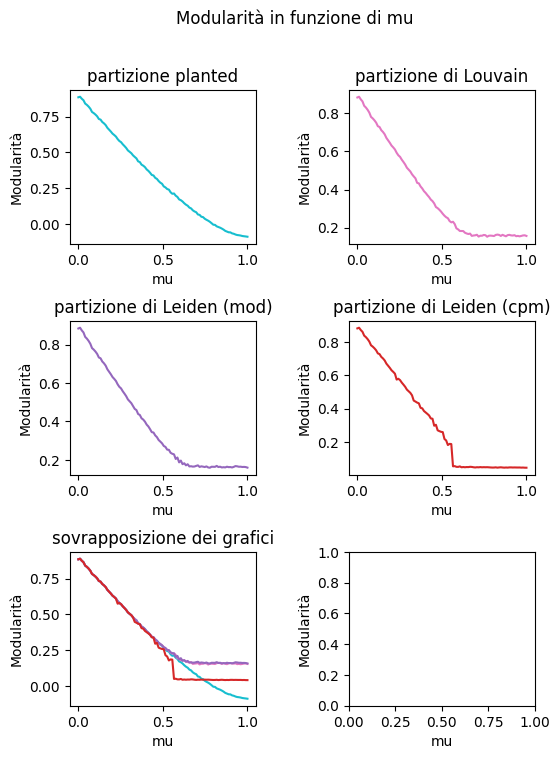

In [56]:
modularità_grafico (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm)

In [57]:
lista_NMI_louvain, lista_NMI_leiden, lista_NMI_leiden_cpm, lista_NMI_loulei = liste_NMI (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm)

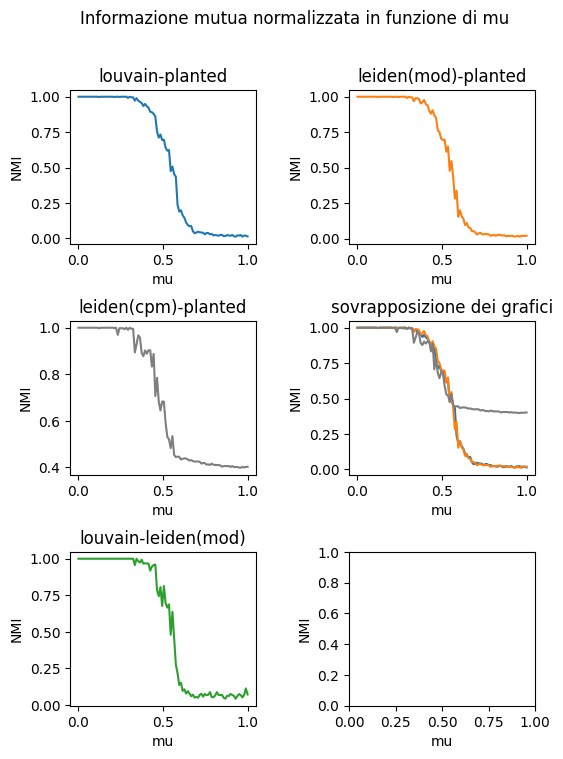

In [58]:
NMI_grafico (lista_NMI_louvain, lista_NMI_leiden, lista_NMI_leiden_cpm, lista_NMI_loulei)

# Analisi sui grafi al variare di mu e della dimensione delle comunità

In [ ]:
def mia_benchmark_variano_mu_e_dimensioni (n, fun1, fun2, min_grado, arr_dim_min, arr_dim_max, argomenti1, argomenti2, intervalli_mu):

    intervalli_dims = len(arr_dim_min)
    arr_dimensioni = []
    max_grado = math.inf

    for i in range (intervalli_dims):
        min_com = arr_dim_min[i]
        max_com = arr_dim_max[i]

        dimensioni = genera_dimensioni (n, fun2, min_com, max_com, argomenti2)
        print(min_com, max_com, dimensioni)
        max_grado = min(max_grado, max(dimensioni))
        arr_dimensioni.append(dimensioni)

    gradi = genera_grado (n, fun1, min_grado, max_grado, argomenti1)
    res = []

    for i in range (intervalli_dims):
        dimensioni = arr_dimensioni[i]

        mu=0

        while mu <= 1:

            comunità = genera_comunità (gradi, dimensioni, mu, 10000)

            G = genera_grafo (n, mu, gradi, comunità)
            res.append((G, comunità))
            mu += 1/intervalli_mu

        print(f'iterazione {i}, comunità nella partizione: {len(dimensioni)}')
    return res

In [ ]:
arr_dim_min = [int(i) for i in (np.linspace(20, 50, 21))]
arr_dim_max = [int(i) for i in (np.linspace(50, 100, 21))]

In [ ]:
grafi_partizioni = mia_benchmark_variano_mu_e_dimensioni (n, fun1, fun2, min_grado, arr_dim_min, arr_dim_max, arg1, arg2, intervalli_mu)

20 50 [49, 46, 46, 44, 43, 42, 41, 41, 39, 35, 35, 34, 34, 29, 28, 27, 27, 26, 26, 25, 25, 25, 24, 24, 24, 21, 20, 20, 20, 20, 20, 20, 20]
21 52 [51, 50, 44, 42, 41, 39, 39, 39, 38, 37, 36, 36, 35, 35, 34, 32, 32, 31, 29, 29, 28, 28, 28, 27, 27, 25, 24, 22, 21, 21]
23 55 [52, 49, 48, 40, 38, 36, 36, 35, 35, 35, 33, 33, 33, 33, 32, 32, 31, 31, 29, 29, 28, 28, 27, 26, 26, 25, 25, 25, 24, 23, 23]
24 57 [56, 56, 53, 53, 51, 50, 49, 47, 46, 45, 42, 41, 38, 37, 37, 37, 36, 34, 33, 32, 27, 26, 26, 24, 24]
26 60 [60, 58, 57, 56, 55, 52, 48, 46, 44, 43, 41, 40, 39, 35, 35, 33, 32, 30, 29, 29, 29, 29, 28, 26, 26]
27 62 [61, 58, 56, 54, 51, 45, 44, 42, 39, 38, 37, 35, 35, 34, 33, 32, 31, 29, 29, 28, 27, 27, 27, 27, 27, 27, 27]
29 65 [63, 54, 52, 50, 46, 44, 43, 42, 41, 39, 39, 38, 36, 36, 34, 34, 34, 33, 32, 32, 31, 31, 29, 29, 29, 29]
30 67 [63, 62, 58, 58, 57, 57, 55, 54, 52, 50, 48, 47, 47, 45, 43, 39, 38, 35, 32, 30, 30]
32 70 [62, 62, 59, 58, 54, 51, 51, 51, 50, 49, 47, 45, 43, 42, 41, 38, 3

In [ ]:
it_interne = intervalli_mu
it_esterne = len(arr_dim_min)

In [ ]:
X = np.linspace(0, 1, intervalli_mu)
Y = arr_dim_min

In [ ]:
coefficienti_clustering = matrice_coefficiente_clustering(grafi_partizioni, it_interne, it_esterne)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


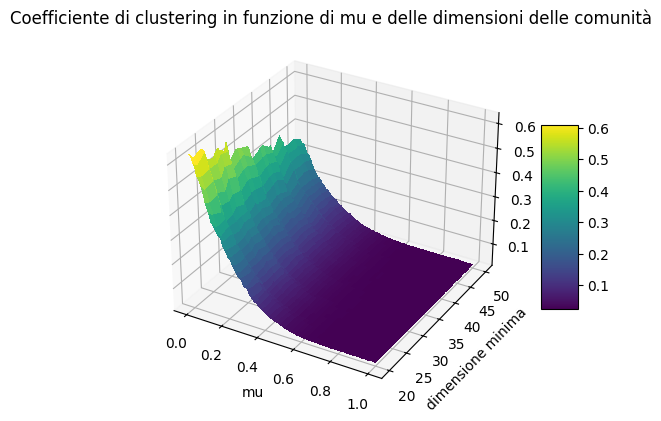

In [ ]:
tridimensional_plot(X,Y,coefficienti_clustering, cm.viridis, 'Coefficiente di clustering in funzione di mu e delle dimensioni delle comunità', 'dimensione minima' )

In [ ]:
lista_louvain, lista_leiden, lista_leiden_cpm = liste_louvain_leiden (grafi_partizioni, lista_gamma*it_esterne)

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0


In [ ]:
Z1, Z2, Z3, Z4 = matrice_modularità (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm, it_interne, it_esterne)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


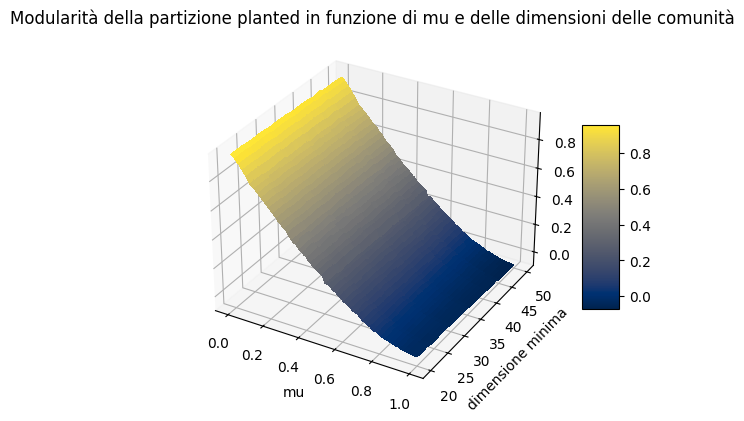

In [ ]:
tridimensional_plot(X,Y,Z1,cm.cividis, 'Modularità della partizione planted in funzione di mu e delle dimensioni delle comunità', 'dimensione minima')

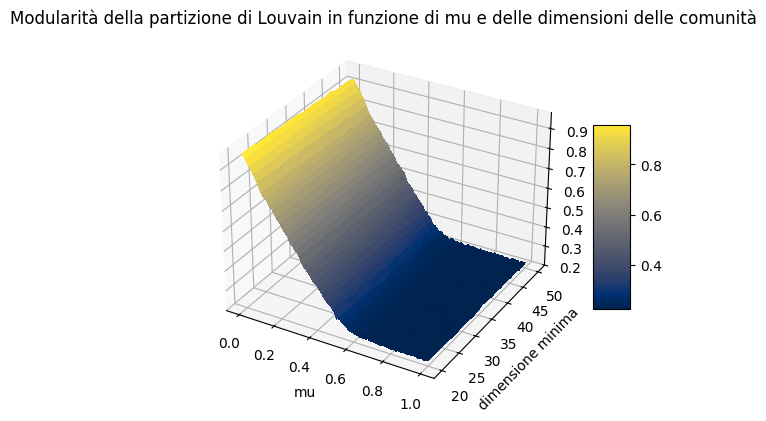

In [ ]:
tridimensional_plot(X,Y,Z2,cm.cividis, 'Modularità della partizione di Louvain in funzione di mu e delle dimensioni delle comunità', 'dimensione minima')

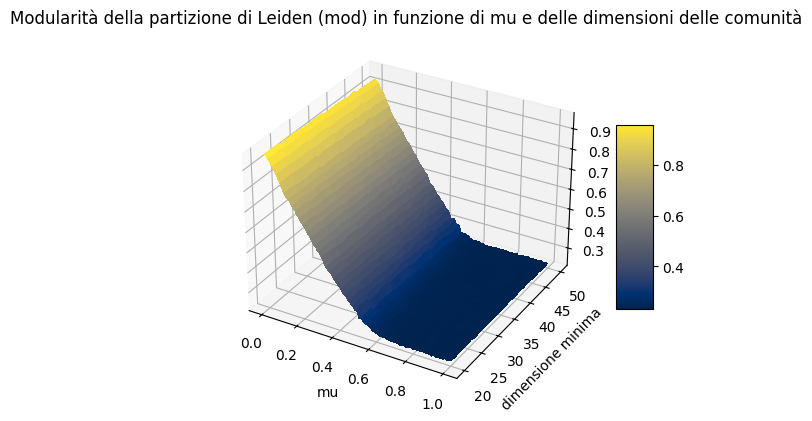

In [ ]:
tridimensional_plot(X,Y,Z3, cm.cividis, 'Modularità della partizione di Leiden (mod) in funzione di mu e delle dimensioni delle comunità', 'dimensione minima')

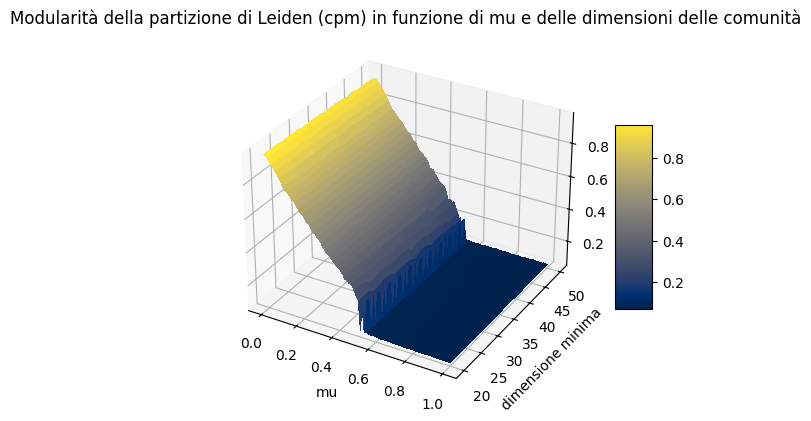

In [ ]:
tridimensional_plot(X,Y,Z4, cm.cividis, 'Modularità della partizione di Leiden (cpm) in funzione di mu e delle dimensioni delle comunità', 'dimensione minima')

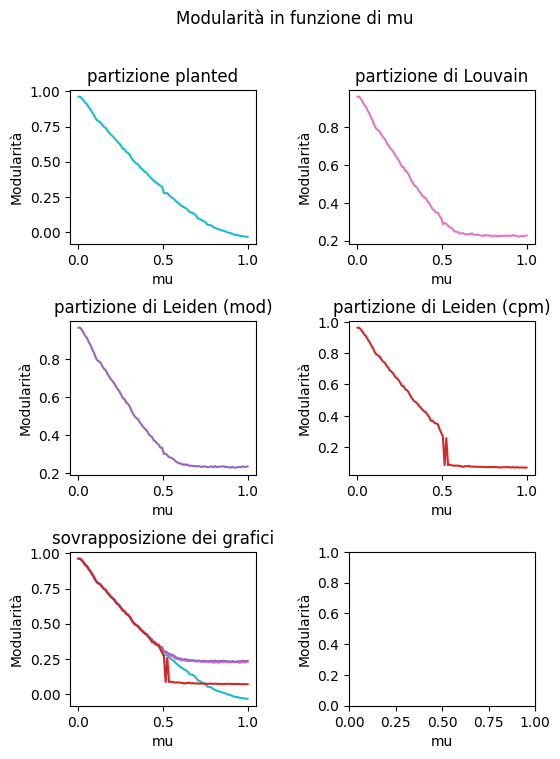

In [ ]:
modularità_grafico (grafi_partizioni[:it_interne], lista_louvain[:it_interne], lista_leiden[:it_interne], lista_leiden_cpm[:it_interne])

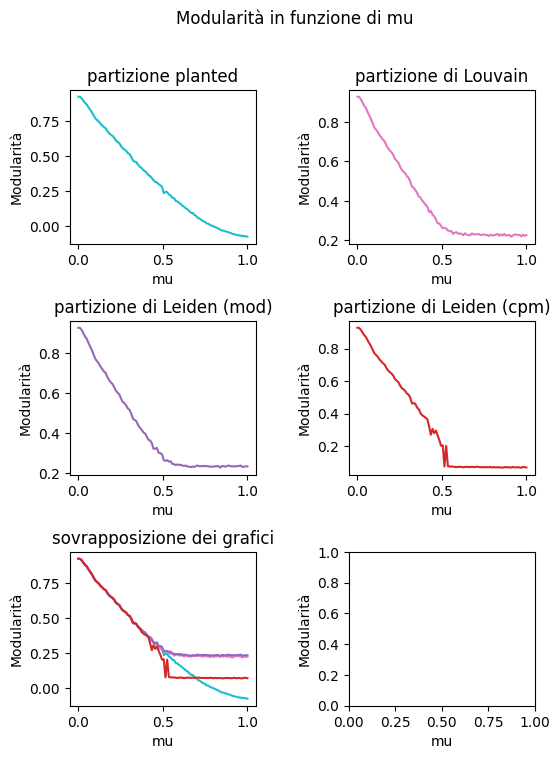

In [ ]:
modularità_grafico (grafi_partizioni[it_interne*(it_esterne-1):it_interne*it_esterne], lista_louvain[it_interne*(it_esterne-1):it_interne*it_esterne], lista_leiden[it_interne*(it_esterne-1):it_interne*it_esterne], lista_leiden_cpm[it_interne*(it_esterne-1):it_interne*it_esterne])

In [ ]:
matrice_NMI_louvain, matrice_NMI_leiden, matrice_NMI_leiden_cpm, matrice_NMI_loulei = matrice_NMI (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm, it_interne, it_esterne)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


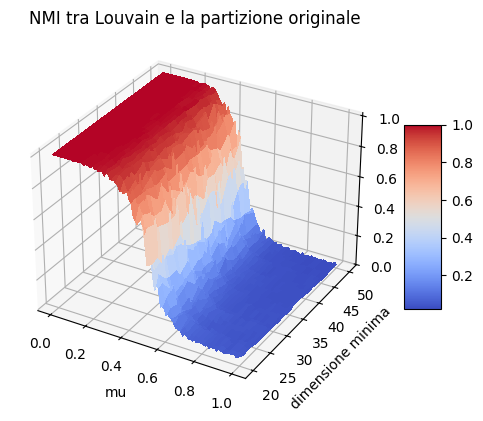

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_louvain, cm.coolwarm, 'NMI tra Louvain e la partizione originale', 'dimensione minima')

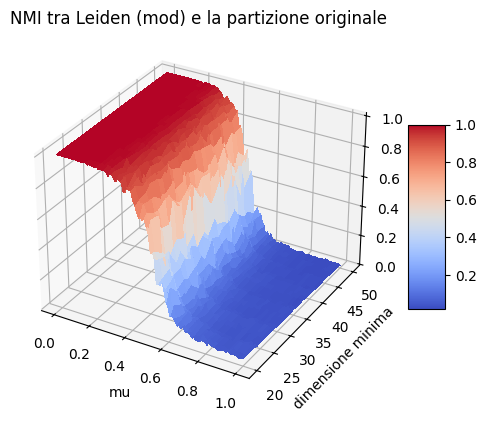

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_leiden, cm.coolwarm, 'NMI tra Leiden (mod) e la partizione originale', 'dimensione minima')

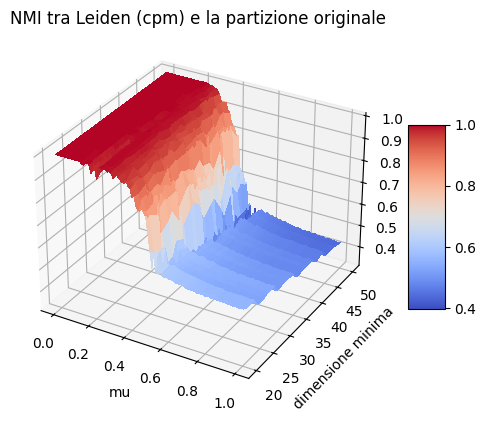

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_leiden_cpm, cm.coolwarm, 'NMI tra Leiden (cpm) e la partizione originale', 'dimensione minima')

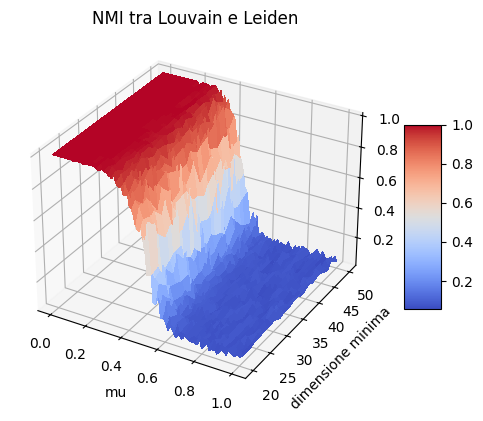

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_loulei, cm.coolwarm, 'NMI tra Louvain e Leiden', 'dimensione minima')

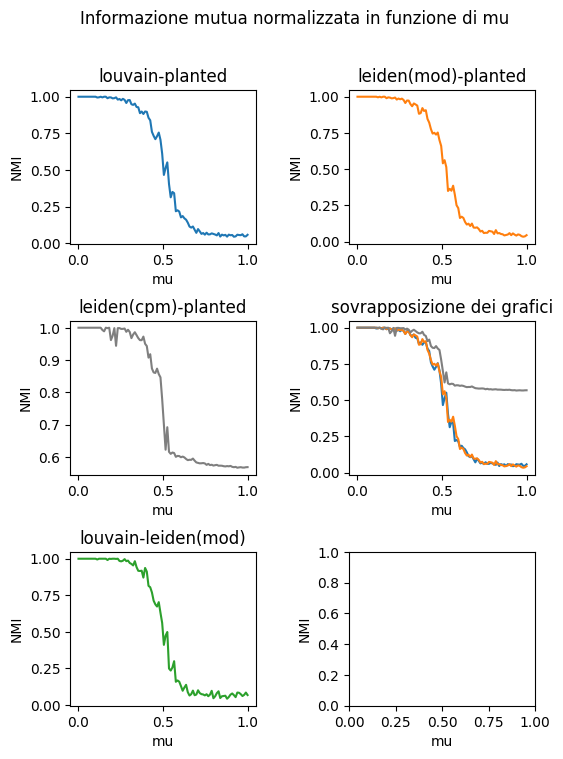

In [ ]:
NMI_grafico (matrice_NMI_louvain[0], matrice_NMI_leiden[0], matrice_NMI_leiden_cpm[0], matrice_NMI_loulei[0])

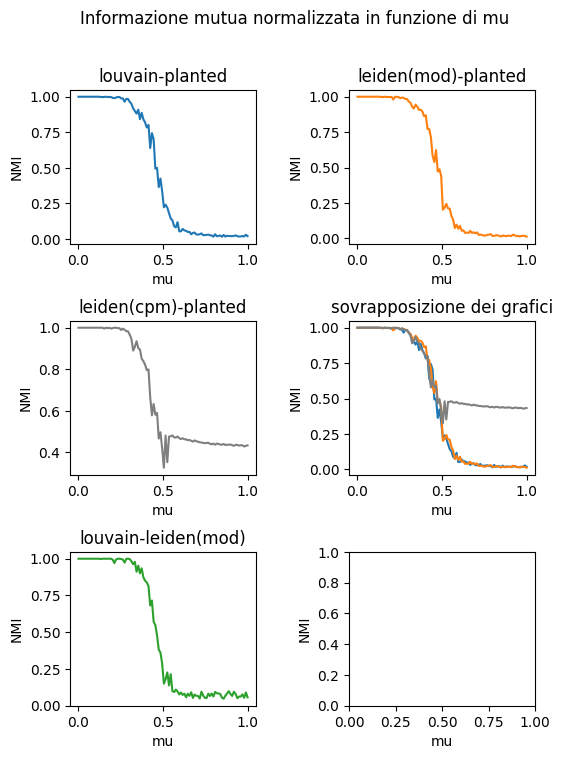

In [ ]:
NMI_grafico (matrice_NMI_louvain[it_esterne-1], matrice_NMI_leiden[it_esterne-1], matrice_NMI_leiden_cpm[it_esterne-1], matrice_NMI_loulei[it_esterne-1])

# Analisi sui grafi al variare di mu e del grado minimo dei nodi

In [ ]:
def mia_benchmark_variano_mu_e_gradi (n, fun1, fun2, arr_min_grado, min_communitysize, max_communitysize, argomenti1, argomenti2, intervalli_mu):

  dimensioni = genera_dimensioni (n, fun2, min_communitysize, max_communitysize, argomenti2)

  max_grado = max(dimensioni)
  res = []
  for i in range (len(arr_min_grado)):
    min_grado = arr_min_grado[i]

    gradi = genera_grado (n, fun1, min_grado, max_grado, argomenti1)

    mu=0
    while mu <= 1:

        comunità = genera_comunità (gradi, dimensioni, mu, 10000)

        G = genera_grafo (n, mu, gradi, comunità)

        res.append((G, comunità))
        mu += 1/intervalli_mu
    print(f'iterazione {i}, media della sequenza dei gradi: {sum(gradi)/len(gradi)}')

  return res

In [ ]:
arr_min_grado = np.array(list(range(2,22, 2)))

In [ ]:
grafi_partizioni = mia_benchmark_variano_mu_e_gradi(n, fun1, fun2, arr_min_grado, min_communitysize, max_communitysize, arg1, arg2, intervalli_mu)

iterazione 0, media della sequenza dei gradi: 7.596
iterazione 1, media della sequenza dei gradi: 14.044
iterazione 2, media della sequenza dei gradi: 20.318
iterazione 3, media della sequenza dei gradi: 24.788
iterazione 4, media della sequenza dei gradi: 29.826
iterazione 5, media della sequenza dei gradi: 33.616
iterazione 6, media della sequenza dei gradi: 36.664
iterazione 7, media della sequenza dei gradi: 40.084
iterazione 8, media della sequenza dei gradi: 44.376
iterazione 9, media della sequenza dei gradi: 48.402


In [ ]:
len(grafi_partizioni)

1000

In [ ]:
len(arr_min_grado)

10

In [ ]:
it_interne = intervalli_mu
it_esterne = len(arr_min_grado)

In [ ]:
X = np.linspace(0, 1, intervalli_mu)
Y = arr_min_grado

In [ ]:
coefficienti_clustering = matrice_coefficiente_clustering(grafi_partizioni, it_interne, it_esterne)

0
1
2
3
4
5
6
7
8
9


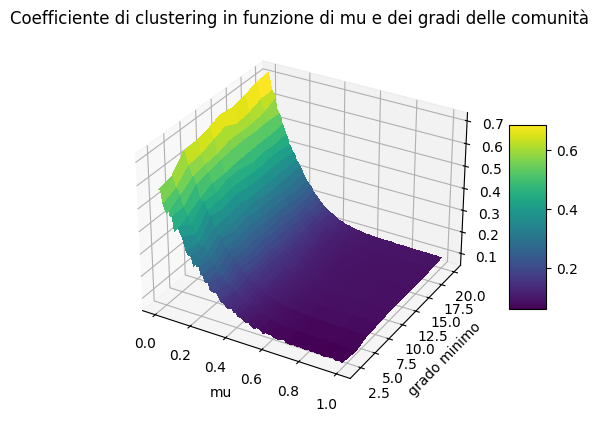

In [ ]:
tridimensional_plot(X,Y,coefficienti_clustering, cm.viridis, 'Coefficiente di clustering in funzione di mu e dei gradi delle comunità', 'grado minimo' )

In [ ]:
lista_louvain, lista_leiden, lista_leiden_cpm = liste_louvain_leiden (grafi_partizioni, lista_gamma*it_esterne)

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0


In [ ]:
Z1, Z2, Z3, Z4 = matrice_modularità (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm, it_interne, it_esterne)

0
1
2
3
4
5
6
7
8
9


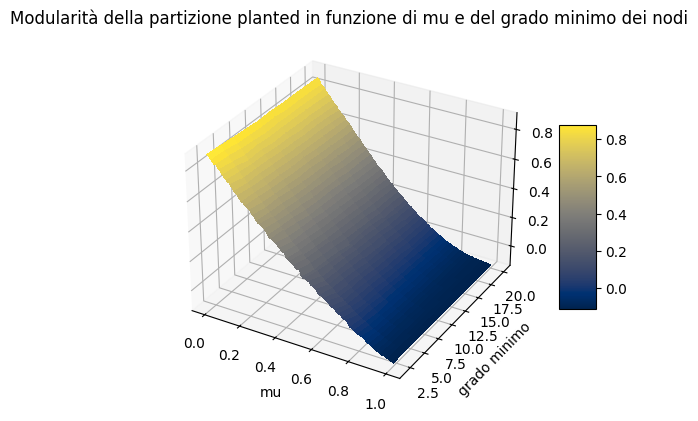

In [ ]:
tridimensional_plot(X,Y,Z1, cm.cividis, 'Modularità della partizione planted in funzione di mu e del grado minimo dei nodi', 'grado minimo')

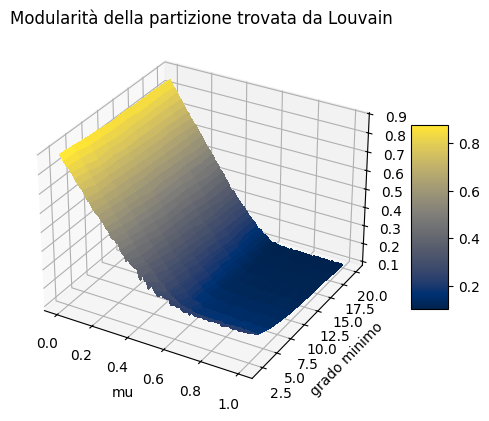

In [ ]:
tridimensional_plot(X,Y,Z2, cm.cividis, 'Modularità della partizione trovata da Louvain', 'grado minimo')

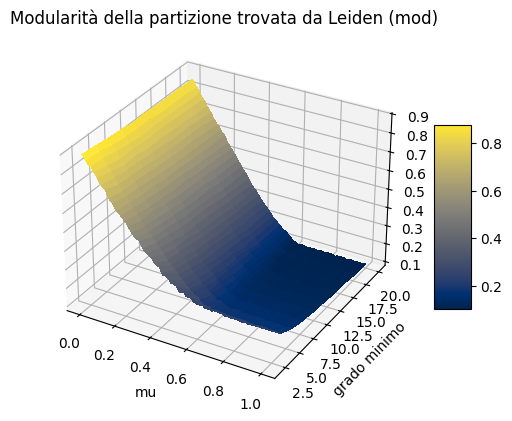

In [ ]:
tridimensional_plot(X,Y,Z3, cm.cividis, 'Modularità della partizione trovata da Leiden (mod)', 'grado minimo')

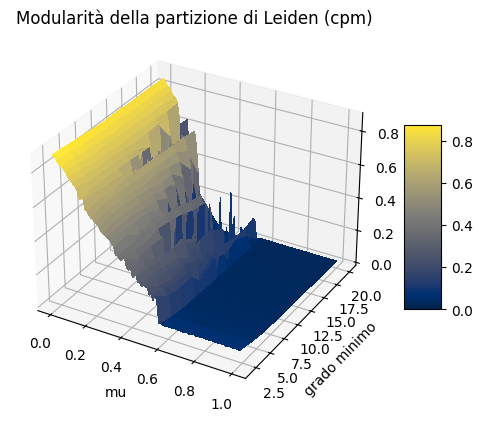

In [ ]:
tridimensional_plot(X,Y,Z4, cm.cividis, 'Modularità della partizione di Leiden (cpm)', 'grado minimo')

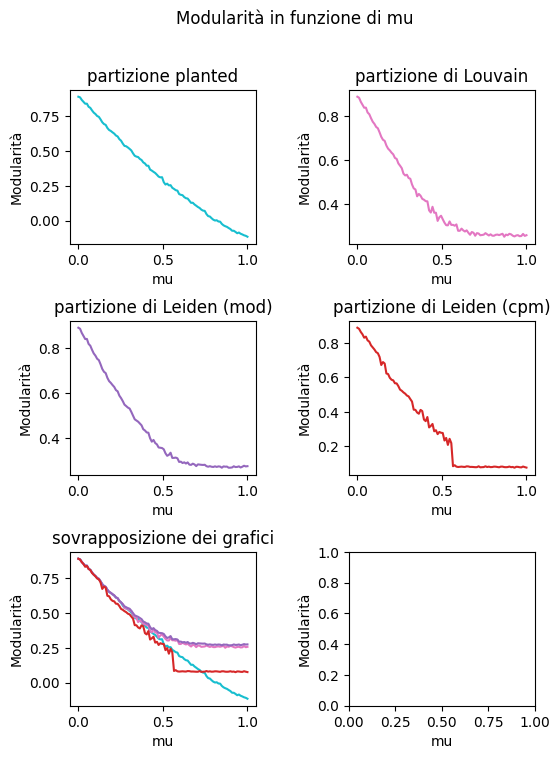

In [ ]:
modularità_grafico (grafi_partizioni[:it_interne], lista_louvain[:it_interne], lista_leiden[:it_interne], lista_leiden_cpm[:it_interne])

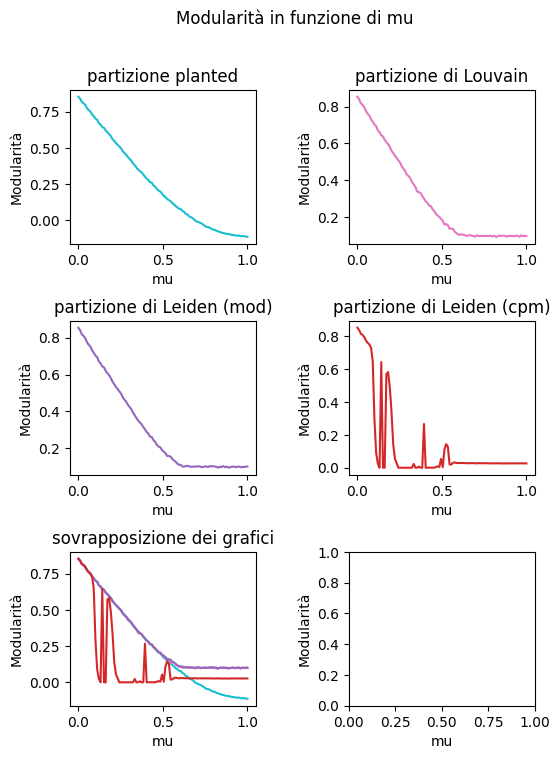

In [ ]:
modularità_grafico (grafi_partizioni[it_interne*(it_esterne-1):it_interne*it_esterne], lista_louvain[it_interne*(it_esterne-1):it_interne*it_esterne], lista_leiden[it_interne*(it_esterne-1):it_interne*it_esterne], lista_leiden_cpm[it_interne*(it_esterne-1):it_interne*it_esterne])

In [ ]:
matrice_NMI_louvain, matrice_NMI_leiden, matrice_NMI_leiden_cpm, matrice_NMI_loulei = matrice_NMI (grafi_partizioni, lista_louvain, lista_leiden, lista_leiden_cpm, it_interne, it_esterne)

0
1
2
3
4
5
6
7
8
9


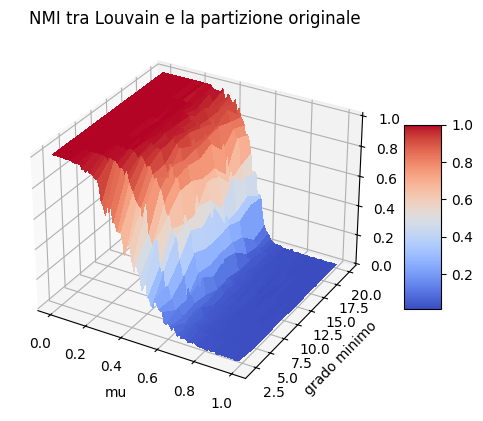

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_louvain, cm.coolwarm, 'NMI tra Louvain e la partizione originale', 'grado minimo')

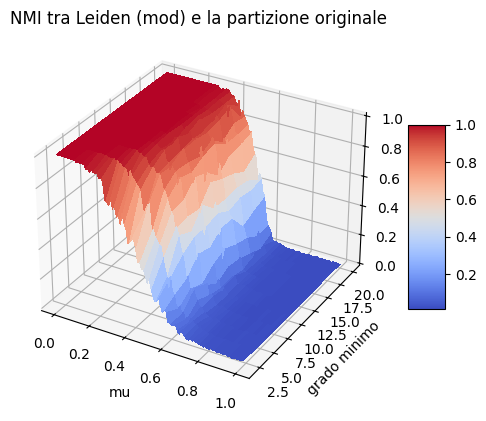

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_leiden, cm.coolwarm, 'NMI tra Leiden (mod) e la partizione originale', 'grado minimo')

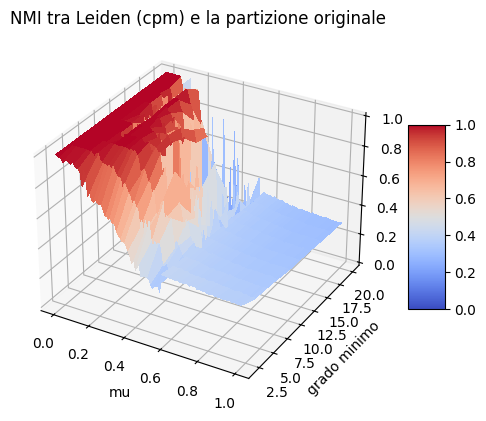

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_leiden_cpm, cm.coolwarm, 'NMI tra Leiden (cpm) e la partizione originale', 'grado minimo')

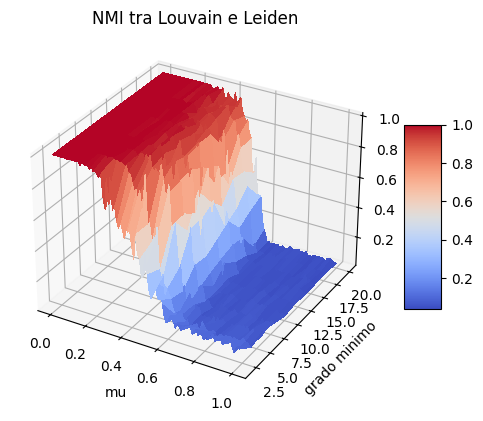

In [ ]:
tridimensional_plot(X,Y,matrice_NMI_loulei, cm.coolwarm, 'NMI tra Louvain e Leiden', 'grado minimo')

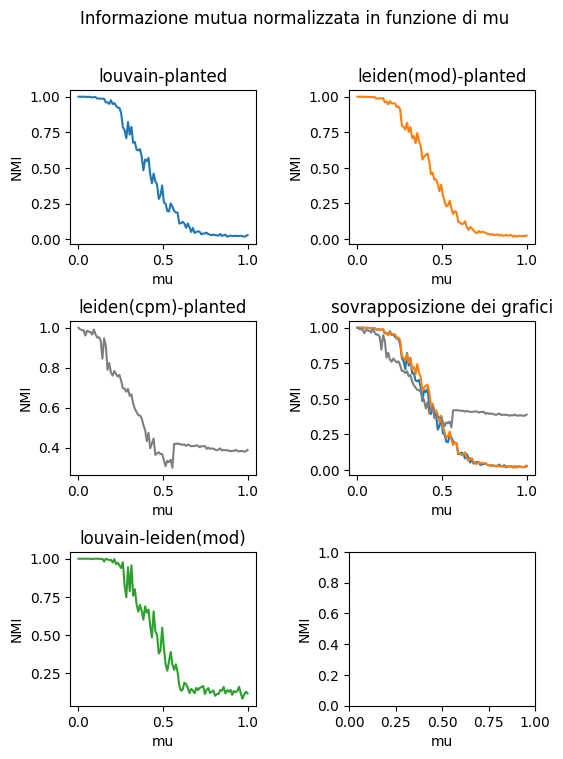

In [ ]:
NMI_grafico (matrice_NMI_louvain[0], matrice_NMI_leiden[0], matrice_NMI_leiden_cpm[0], matrice_NMI_loulei[0])

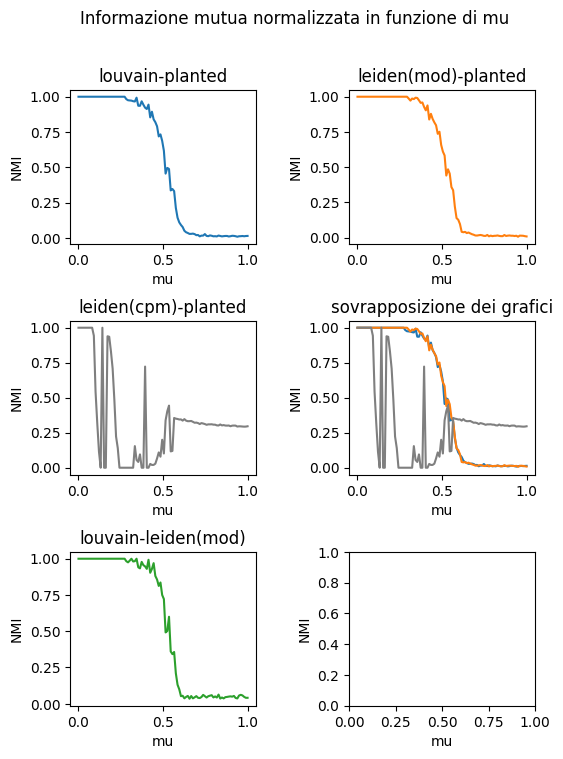

In [ ]:
NMI_grafico (matrice_NMI_louvain[it_esterne-1], matrice_NMI_leiden[it_esterne-1], matrice_NMI_leiden_cpm[it_esterne-1], matrice_NMI_loulei[it_esterne-1])